# Task-3-
Build a decision tree classifier to predict whether a customer will purchase a product or service based on their demographic and behavioral data. Use a dataset such as the Bank Marketing dataset from the UCI Machine Learning Repository. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report


In [2]:
# Load dataset
data = pd.read_csv("bank-additional.csv", delimiter=";")


In [4]:
print(data.columns)


Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


In [7]:
# Define categorical columns
categorical_col = ['job', 'marital', 'education', 'default', 'housing', 
                   'loan', 'contact', 'month', 'day_of_week', 'poutcome']

# Encode categorical columns
le = LabelEncoder()
for col in categorical_col:
    data[col] = le.fit_transform(data[col])

# Verifying  the encoded dataset
print(data.head())

   age  job  marital  education  default  housing  loan  contact  month  \
0   30    1        1          2        0        2     0        0      6   
1   39    7        2          3        0        0     0        1      6   
2   25    7        1          3        0        2     0        1      4   
3   38    7        1          2        0        1     1        1      4   
4   47    0        1          6        0        2     0        0      7   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            0  ...         2    999         0         1          -1.8   
1            0  ...         4    999         0         1           1.1   
2            4  ...         1    999         0         1           1.4   
3            0  ...         3    999         0         1           1.4   
4            1  ...         1    999         0         1          -0.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0          92.893          -46.2      1.3

In [8]:
# Encode the target variable
data["y"] = data["y"].apply(lambda x: 1 if x == "yes" else 0)

# Define features (X) and target (Y)
X = data.drop("y", axis=1)
Y = data["y"]

In [10]:
# Check class distribution
print("Class Distribution:\n", Y.value_counts(normalize=True))

Class Distribution:
 y
0    0.890507
1    0.109493
Name: proportion, dtype: float64


In [11]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

In [12]:
# Initialize and train the Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=4, min_samples_split=20, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_split=20, random_state=42)

In [13]:
# Predict on the test set
y_pred = clf.predict(X_test)

In [15]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8462783171521036

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.91      1101
           1       0.40      0.87      0.55       135

    accuracy                           0.85      1236
   macro avg       0.69      0.86      0.73      1236
weighted avg       0.92      0.85      0.87      1236



In [16]:
# Feature importance
feature_importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", feature_importances)


Feature Importances:
 duration          0.580879
nr.employed       0.219628
euribor3m         0.117650
cons.conf.idx     0.058887
month             0.015956
contact           0.004000
campaign          0.003000
pdays             0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
poutcome          0.000000
previous          0.000000
marital           0.000000
education         0.000000
job               0.000000
day_of_week       0.000000
loan              0.000000
housing           0.000000
default           0.000000
age               0.000000
dtype: float64


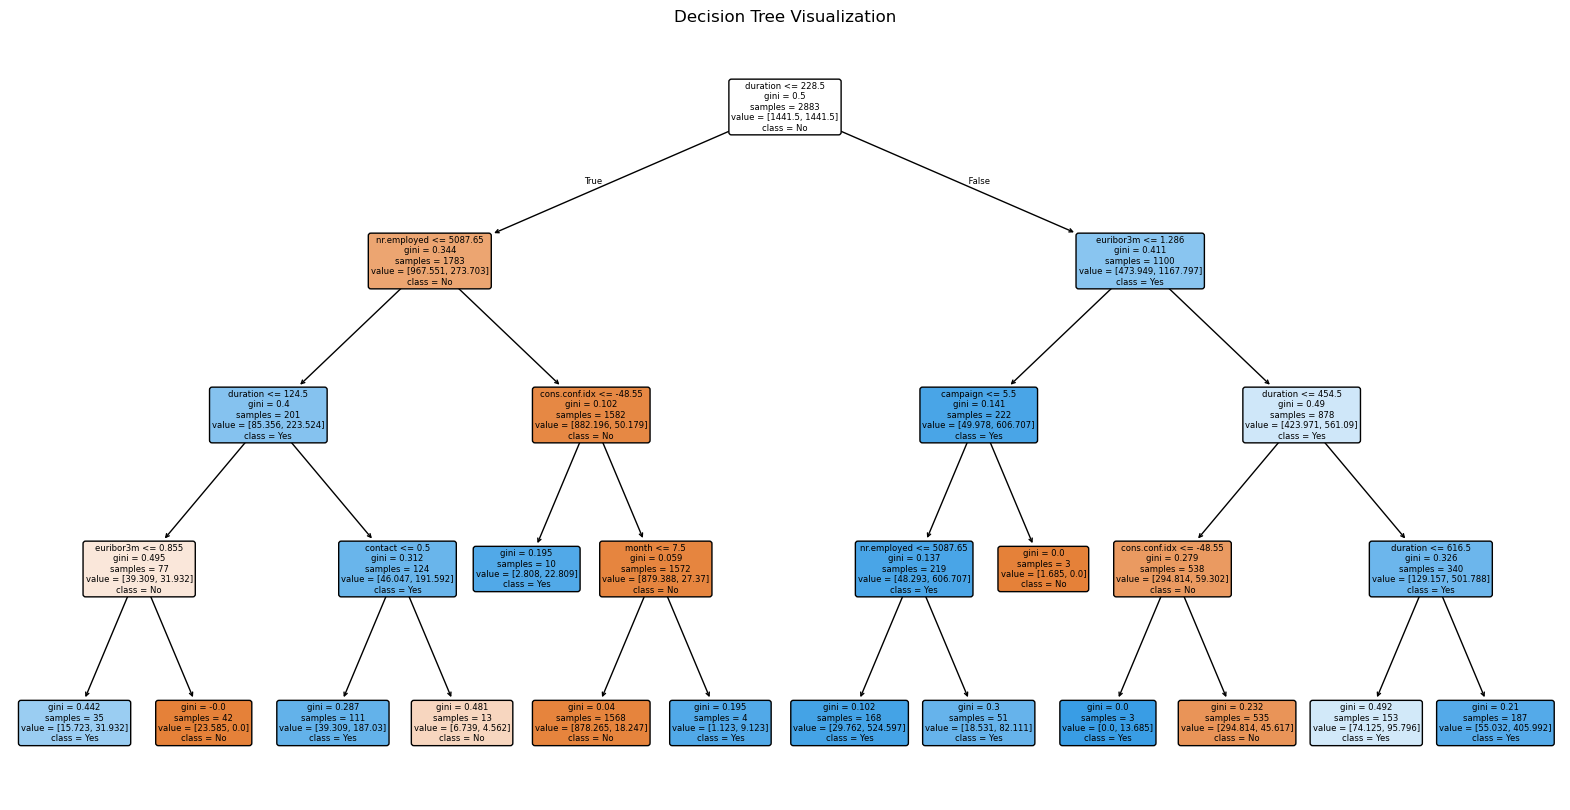

In [17]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["No", "Yes"], filled=True, rounded=True)
plt.title("Decision Tree Visualization")
plt.show()